In [2]:
%pip install sympy
import sympy as sp
from control import tf, step_response, poles, zeros, pzmap
import matplotlib.pyplot as plt
import numpy as np

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------- ----------------------- 2.6/6.3 MB 15.5 MB/s eta 0:00:01
   ------------------------------------ --- 5.8/6.3 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 14.2 MB/s  0:00:00
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 536.2/536.2 kB 11.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   ---------------------------------------- 0/2 [mpmath]
   -------------------------------------

In [3]:
s = sp.symbols('s')
X = sp.symbols('X')
Y = sp.symbols('Y')

A = 2*s**2 * Y + s * Y
B = s * X + X


tf_expr = sp.solve(sp.Eq(A, B), Y)[0] / X
tf_simplified = sp.simplify(tf_expr)

print(f"Calculated Transfer Function G(s): {tf_simplified}")

Calculated Transfer Function G(s): (s + 1)/(s*(2*s + 1))


In [4]:
num_coeffs = [float(c) for c in sp.Poly(sp.numer(tf_simplified), s).all_coeffs()]
den_coeffs = [float(c) for c in sp.Poly(sp.denom(tf_simplified), s).all_coeffs()]

sys = tf(num_coeffs, den_coeffs)
print(sys)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


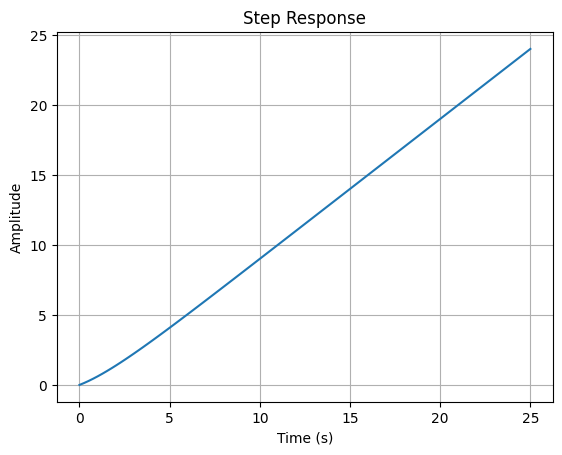

In [5]:
t, y = step_response(sys)

plt.plot(t, y)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


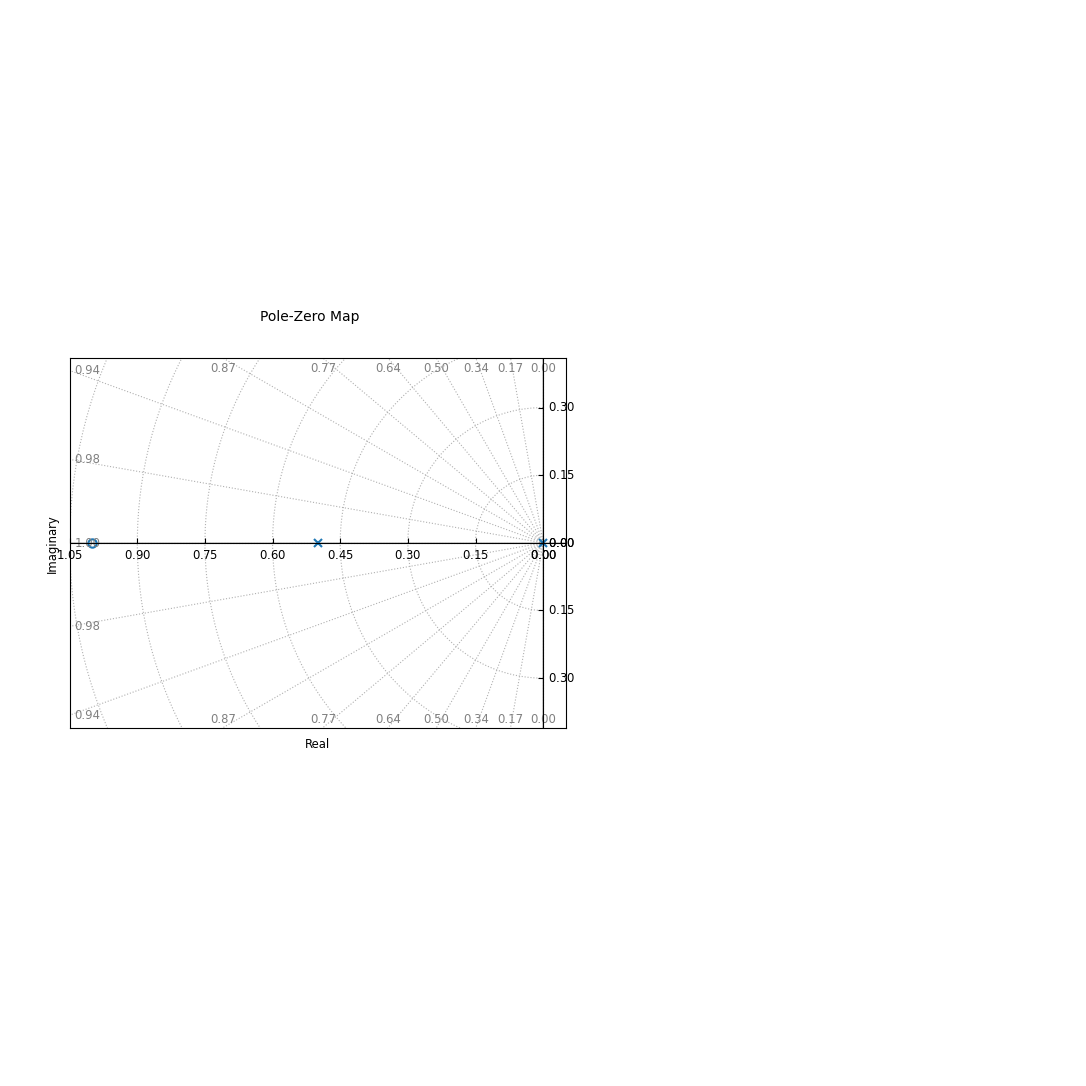

In [6]:
print(f"Poles: {poles(sys)}")
print(f"Zeros: {zeros(sys)}")

pzmap(sys, grid=True, title='Pole-Zero Map')
plt.show()